In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
from matplotlib.gridspec import GridSpec
from scipy.signal import savgol_filter
from pathlib import Path

# store plastic slip rates and temperatures
data = []
maxout = 1000

# plot function for stress and pile-up dislocations
def plot_stress_bfield(npt = 300, file=None, cutoff=100.):
    xpts = np.linspace(0.0, dsl.lx, npt)
    ypts = np.linspace(0.0, dsl.ly, npt)
    XP, YP = np.meshgrid(xpts, ypts)
    s12 = np.zeros((npt, npt), dtype=np.float64)
    for i in range(dsl.Ntot):
        s12 += dsl.bx[i] * dsl.sig_xy(XP - dsl.xpos[i], YP - dsl.ypos[i])
        s12 -= dsl.by[i] * dsl.sig_xy(YP - dsl.ypos[i], XP - dsl.xpos[i])
    extent = (0.0, dsl.lx, 0.0, dsl.ly)
    
    #fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 12), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.0)
    # -----------------------------
    # upper plot: stress field and dislocations
    # -----------------------------
    ax1 = fig.add_subplot(gs[0])
    #ax1.xaxis.set_label_position('top')
    #ax1.set_xlabel(r"x ($\mu$m)")
    ax1.xaxis.tick_top()
    plt.setp(ax1.get_xticklabels(), visible=False)
    ax1.set_ylabel(r"y ($\mu$m)")
    im = ax1.imshow(s12, origin="lower", extent=extent,
        vmin=-cutoff, vmax=cutoff, cmap=plt.cm.RdBu, aspect="equal")
    ax1.scatter(dsl.xpos[:npu], dsl.ypos[:npu], s=10, c="yellow", marker="o")
    cbar = fig.colorbar(im, ax=ax1, pad=0.08)
    #cbar.set_label(r"$\sigma_{12}$ (MPa)")
    cbar.ax.set_title(r"$\sigma_{12}$ (MPa)")
    
    # -----------------------------
    # Lower Plot: b-field
    # -----------------------------
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.plot(dsl.xpos[npu:], dsl.by[npu:], lw=2)  #color=plt.cm.viridis(0)
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(0., dsl.by[npu:].max())
    ax2.invert_yaxis()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    ax2.set_position([
        pos1.x0,
        pos2.y0,
        pos1.width,
        pos2.height
    ])
    ax2.set_ylabel(r"$b_y \, / \, B$")
    ax2.set_xlabel(r"x ($\mu$m)")
    ax2.yaxis.set_label_position('right')
    ax2.yaxis.tick_right()
    if file is not None:
        plt.savefig(file, dpi=300)
    plt.show()

def find_h5_files(directory: str | Path, recursive: bool = False) -> list[Path]:
    """
    Find all .h5 files in a directory.

    Parameters
    ----------
    directory : str | Path
        Directory to search.
    recursive : bool, optional
        If True, search recursively in subdirectories.

    Returns
    -------
    list[Path]
        Sorted list of .h5 files.
    """
    path = Path(directory)

    if not path.is_dir():
        raise NotADirectoryError(f"Not a directory: {path}")

    pattern = "**/*.h5" if recursive else "*.h5"

    return sorted(path.glob(pattern))

def eps_dot(sig, temp, gs):
    Dgb = 10.  # micron^2/micro s
    delta = 0.5  # e-3
    om = 0.25**3  # e-3 **3
    kb = 1.380649e-5  # e-23 / e-6 (tau0) e-3 (delta) e-9 (om)
    ed = 148. * sig * Dgb * delta * om / (gs**3 * kb * temp)
    return ed

In [2]:
path = "../data/Res-tau100/"
flist = find_h5_files(path)
for i, fname in enumerate(flist):
    if "T700" in str(fname):
        continue
    gbdd = dd.GB_dislocations(from_file=fname)
    print(f"Data file with H={gbdd.D2}, L={gbdd.Dgp}, T={gbdd.temp}, tau0={gbdd.tau0}, n={gbdd.Ngbn-1}")
    #gbdd.plot_time_series(['n_slip_dis', 'n_absorbed', 'n_gbdis_eff'])
    #print(f"** Max. time step = {max(gbdd.glob_data['timestep'])}, Median: {np.median(gbdd.glob_data['timestep'])}")
    #print(f"Av. slip rate: {np.mean(gbdd.glob_data['plast_slip_rate'][-100:])}, "
    #      f"Nslip: {np.mean(gbdd.glob_data['n_slip_dis'][-100:])}, Ngb_eff: {np.mean(gbdd.glob_data['n_gbdis_eff'][-100:])}")
    data.append(gbdd)
    hh = gbdd.glob_data["n_slip_dis"][gbdd.nout-100:gbdd.nout]
    hvar = max(hh) - min(hh)
    nhist = np.histogram(hh, bins=int(hvar+1))
    print('*** hvar, hist ***',hvar, nhist, )

Data file with H=10.0, L=0.1, T=800.0, tau0=100.0, n=24
*** hvar, hist *** 0.0 (array([100]), array([141.5, 142.5]))
Data file with H=100.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 2.0 (array([12, 73, 15]), array([397.        , 397.66666667, 398.33333333, 399.        ]))
Data file with H=10.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([52, 48]), array([92. , 92.5, 93. ]))
Data file with H=1.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([61, 39]), array([10. , 10.5, 11. ]))
Data file with H=30.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([10, 90]), array([182. , 182.5, 183. ]))
Data file with H=3.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([60, 40]), array([33. , 33.5, 34. ]))
Data file with H=0.3, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([84, 16]), array([2. , 2.5, 3. ]))
Data file with H=60.0, L=0.1, T=1000.0, tau0=100.0, n=24
*** hvar, hist *** 1.0 (array([24, 7

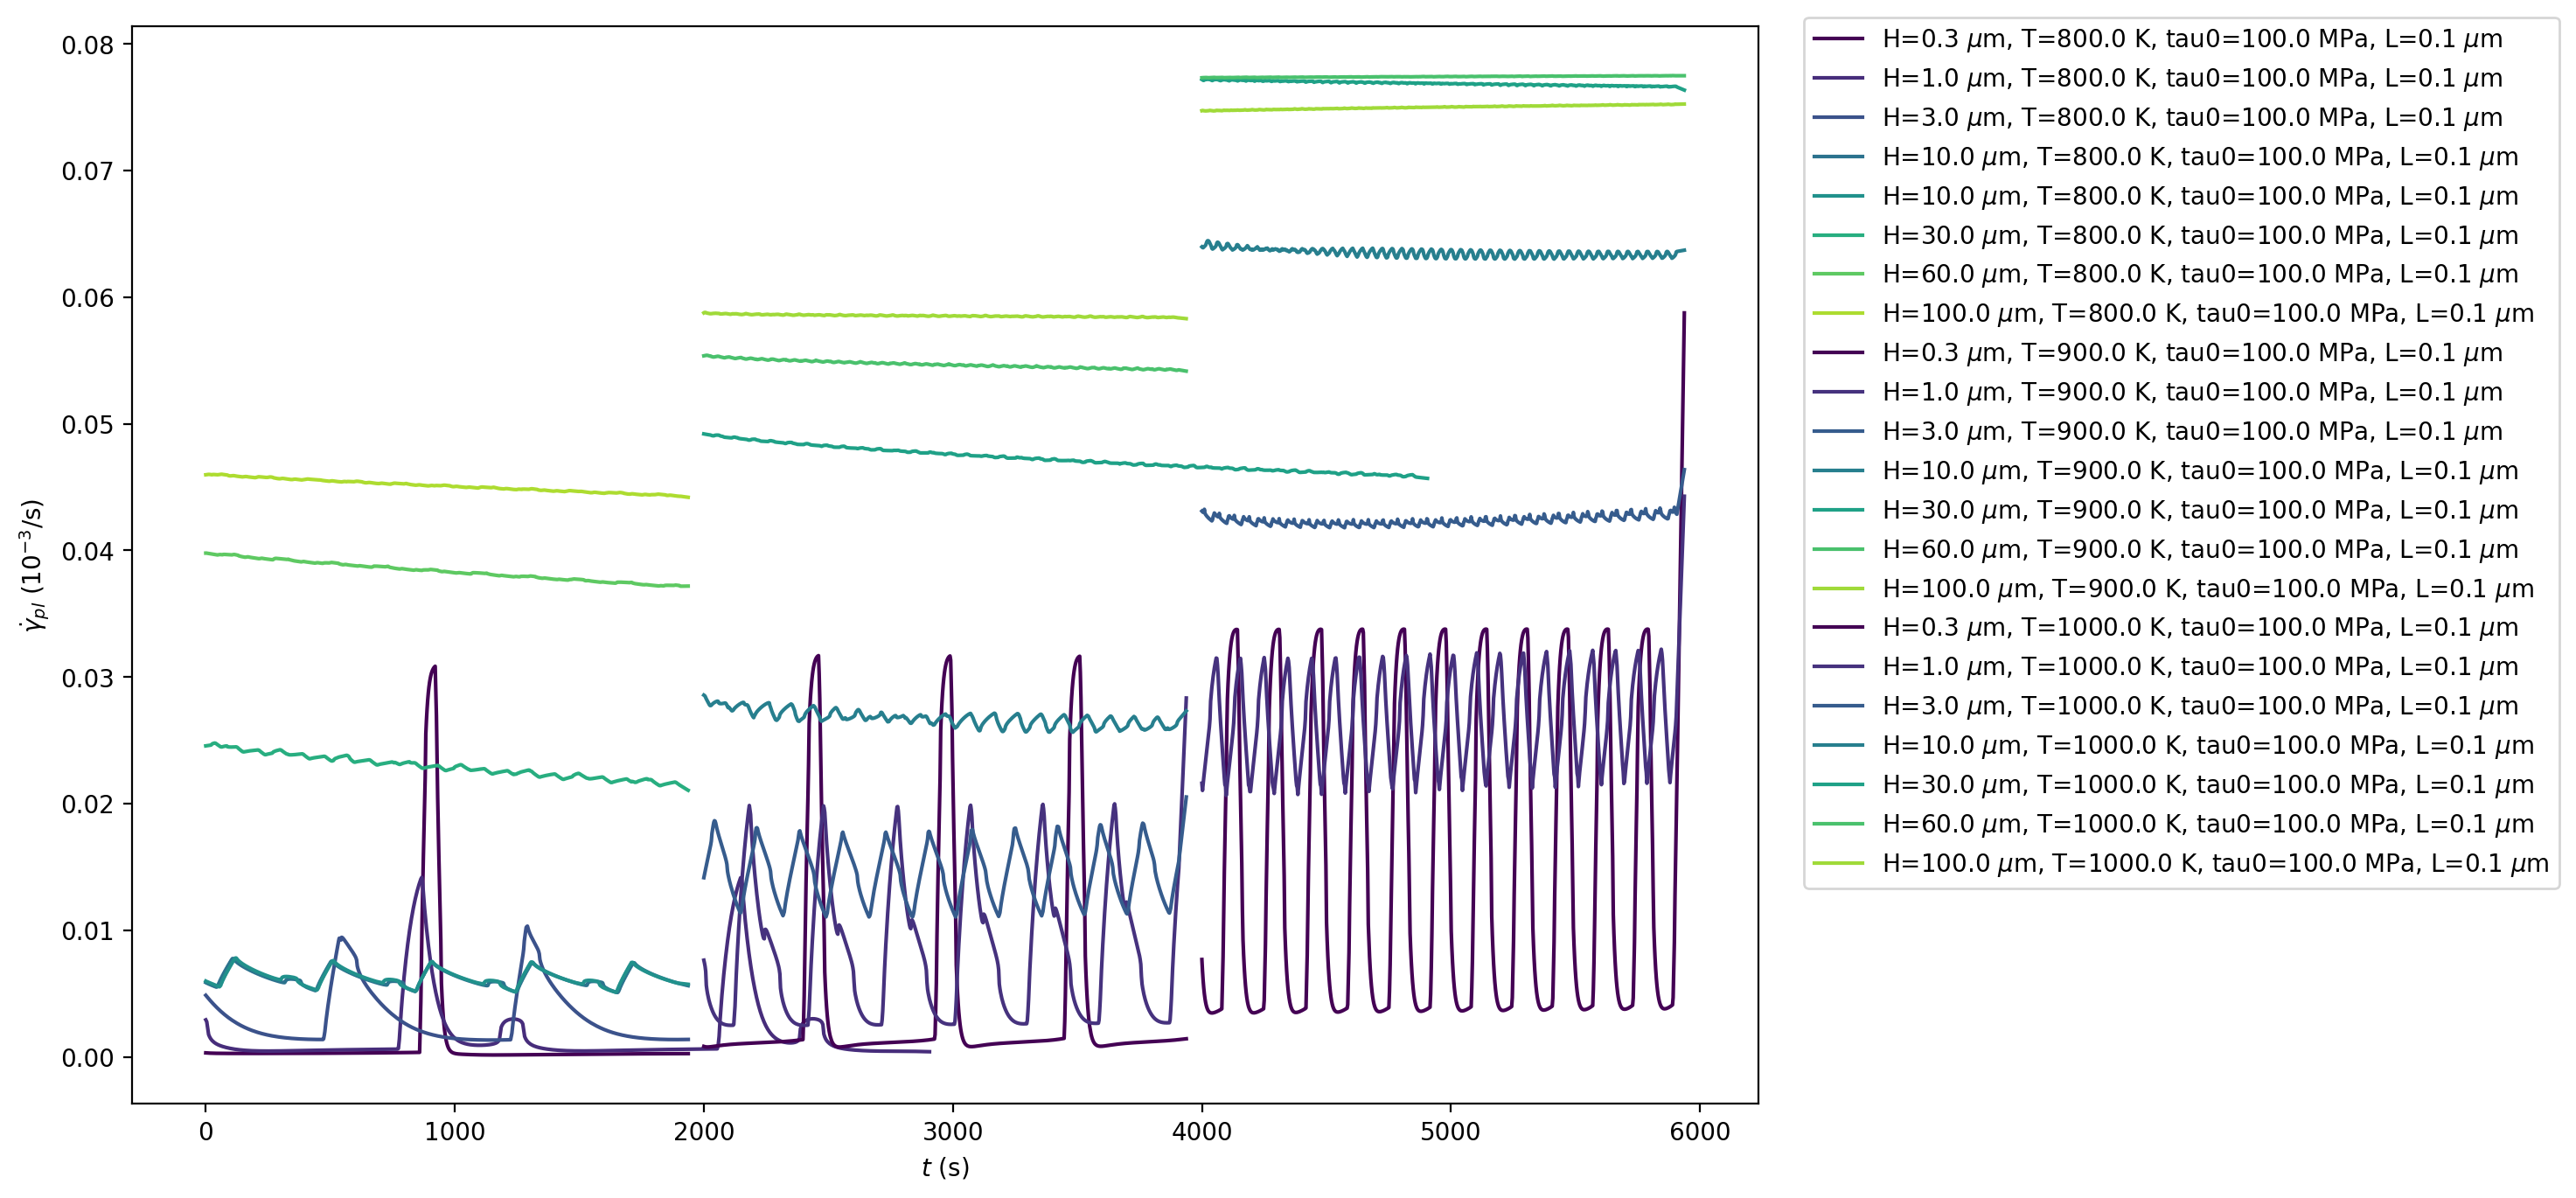

In [3]:
#store data in nd-arrays
num = len(data)
psr_ = np.zeros(num)
temp_ = np.zeros(num)
gs_ = np.zeros(num)
H_ = np.zeros(num)
L_ = np.zeros(num)
tau_ = np.zeros(num)
nit = np.zeros(num, dtype=int)
psr_flt = np.zeros((num, maxout))
stime = np.zeros((num, maxout))

hh_ = np.zeros(num)
for i, ds in enumerate(data):
    hh_[i] = ds.D2
isort = np.argsort(hh_)

for i, j in enumerate(isort):
    ds = data[j]
    nit[i] = ds.nout
    stime[i, :nit[i]] = ds.sim_time
    gs_[i] = ds.D2
    temp_[i] = ds.temp
    H_[i] = ds.D2
    L_[i] = ds.Dgp
    tau_[i] = ds.tau0
    #gplast = ds.glob_data['plastic_slip']
    psr_[i] = np.mean(ds.glob_data['plast_slip_rate'][ds.nout//10:-5])
    wl = min(25, int(ds.nout * 0.1))
    if wl < 2:
        print(f"Warning window length for savgol filter too small: {wl}; too few output items: {ds.nout}")
        psr_flt[i, :nit[i]] = ds.glob_data['psr_av']
    else:
        psr_flt[i, :nit[i]-5] = savgol_filter(ds.glob_data['psr_av'][:-5], window_length=wl, polyorder=1, deriv=0)

plt.rcParams["font.size"] = 10
ioffs=20
tapp = [800, 900, 1000]
hfac = lambda x: np.log(x/min(H_)) / np.log(max(H_)/min(H_))
ngbl = 0.1
cmap = plt.cm.viridis  #plasma
plfun = plt.plot  # semilogy
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
for k, t in enumerate(tapp):
    ind = np.nonzero(np.logical_and(np.isclose(temp_, t), np.isclose(L_, ngbl)))[0]
    for j, i in enumerate(ind):
        cx = j/len(ind)
        col = cmap(cx)
        xval = stime[i, ioffs:nit[i]-5] - stime[i, ioffs]
        plfun(xval*1.e-6 + 2000*k,
             psr_flt[i, ioffs:nit[i]-5]*1.e9,
             marker="none",
             linestyle="solid", 
             color=col,
             label=f"H={gs_[i]}"+r" $\mu$m, " + f"T={temp_[i]} K, tau0={tau_[i]} MPa, L={L_[i]}"+r" $\mu$m"
             )
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 1.02))
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$\dot\gamma_{pl}$ (10$^{-3}$/s)")
#plt.savefig('pu1_conv_gd_ngbn_semilog.pdf', dpi=300, format='pdf')
plt.show()

In [28]:
R = 8.314
Q0 = 3.0e4 #70197 #
C0 = 5.e-6 #5.32e-4 #

hmax = 160
Ceff = C0 * np.sqrt(hmax)
def edot_ss(H, tau, T, C=Ceff):
    H0 = hmax - 0.5*(T-800)
    return C * tau * np.exp(-Q0 / (R*T)) * (H/H0)**0.5 / (1 + (H/H0)**1.)

def err(x, edref, T, tau=50):
    ev = 0.
    nv = edref.shape[1]
    for i in range(nv):
        if edref[0, i] < 2.:
            continue
        hh = np.abs(1. - edref[1, i] / edot_ss(H=edref[0, i], tau=tau, T=T, C=x))
        #print(f'H: {edref[0, i]}, epsd: {edref[1, i]}, err: {hh}')
        ev += hh
    return ev / nv
    

Mean abs. rel. error for T=1000K: 0.7126958018518171
Mean abs. rel. error for T=900K: 0.7115234000484337
Mean abs. rel. error for T=800K: 0.7091242309212638
Mean total error: 0.7111144776071715


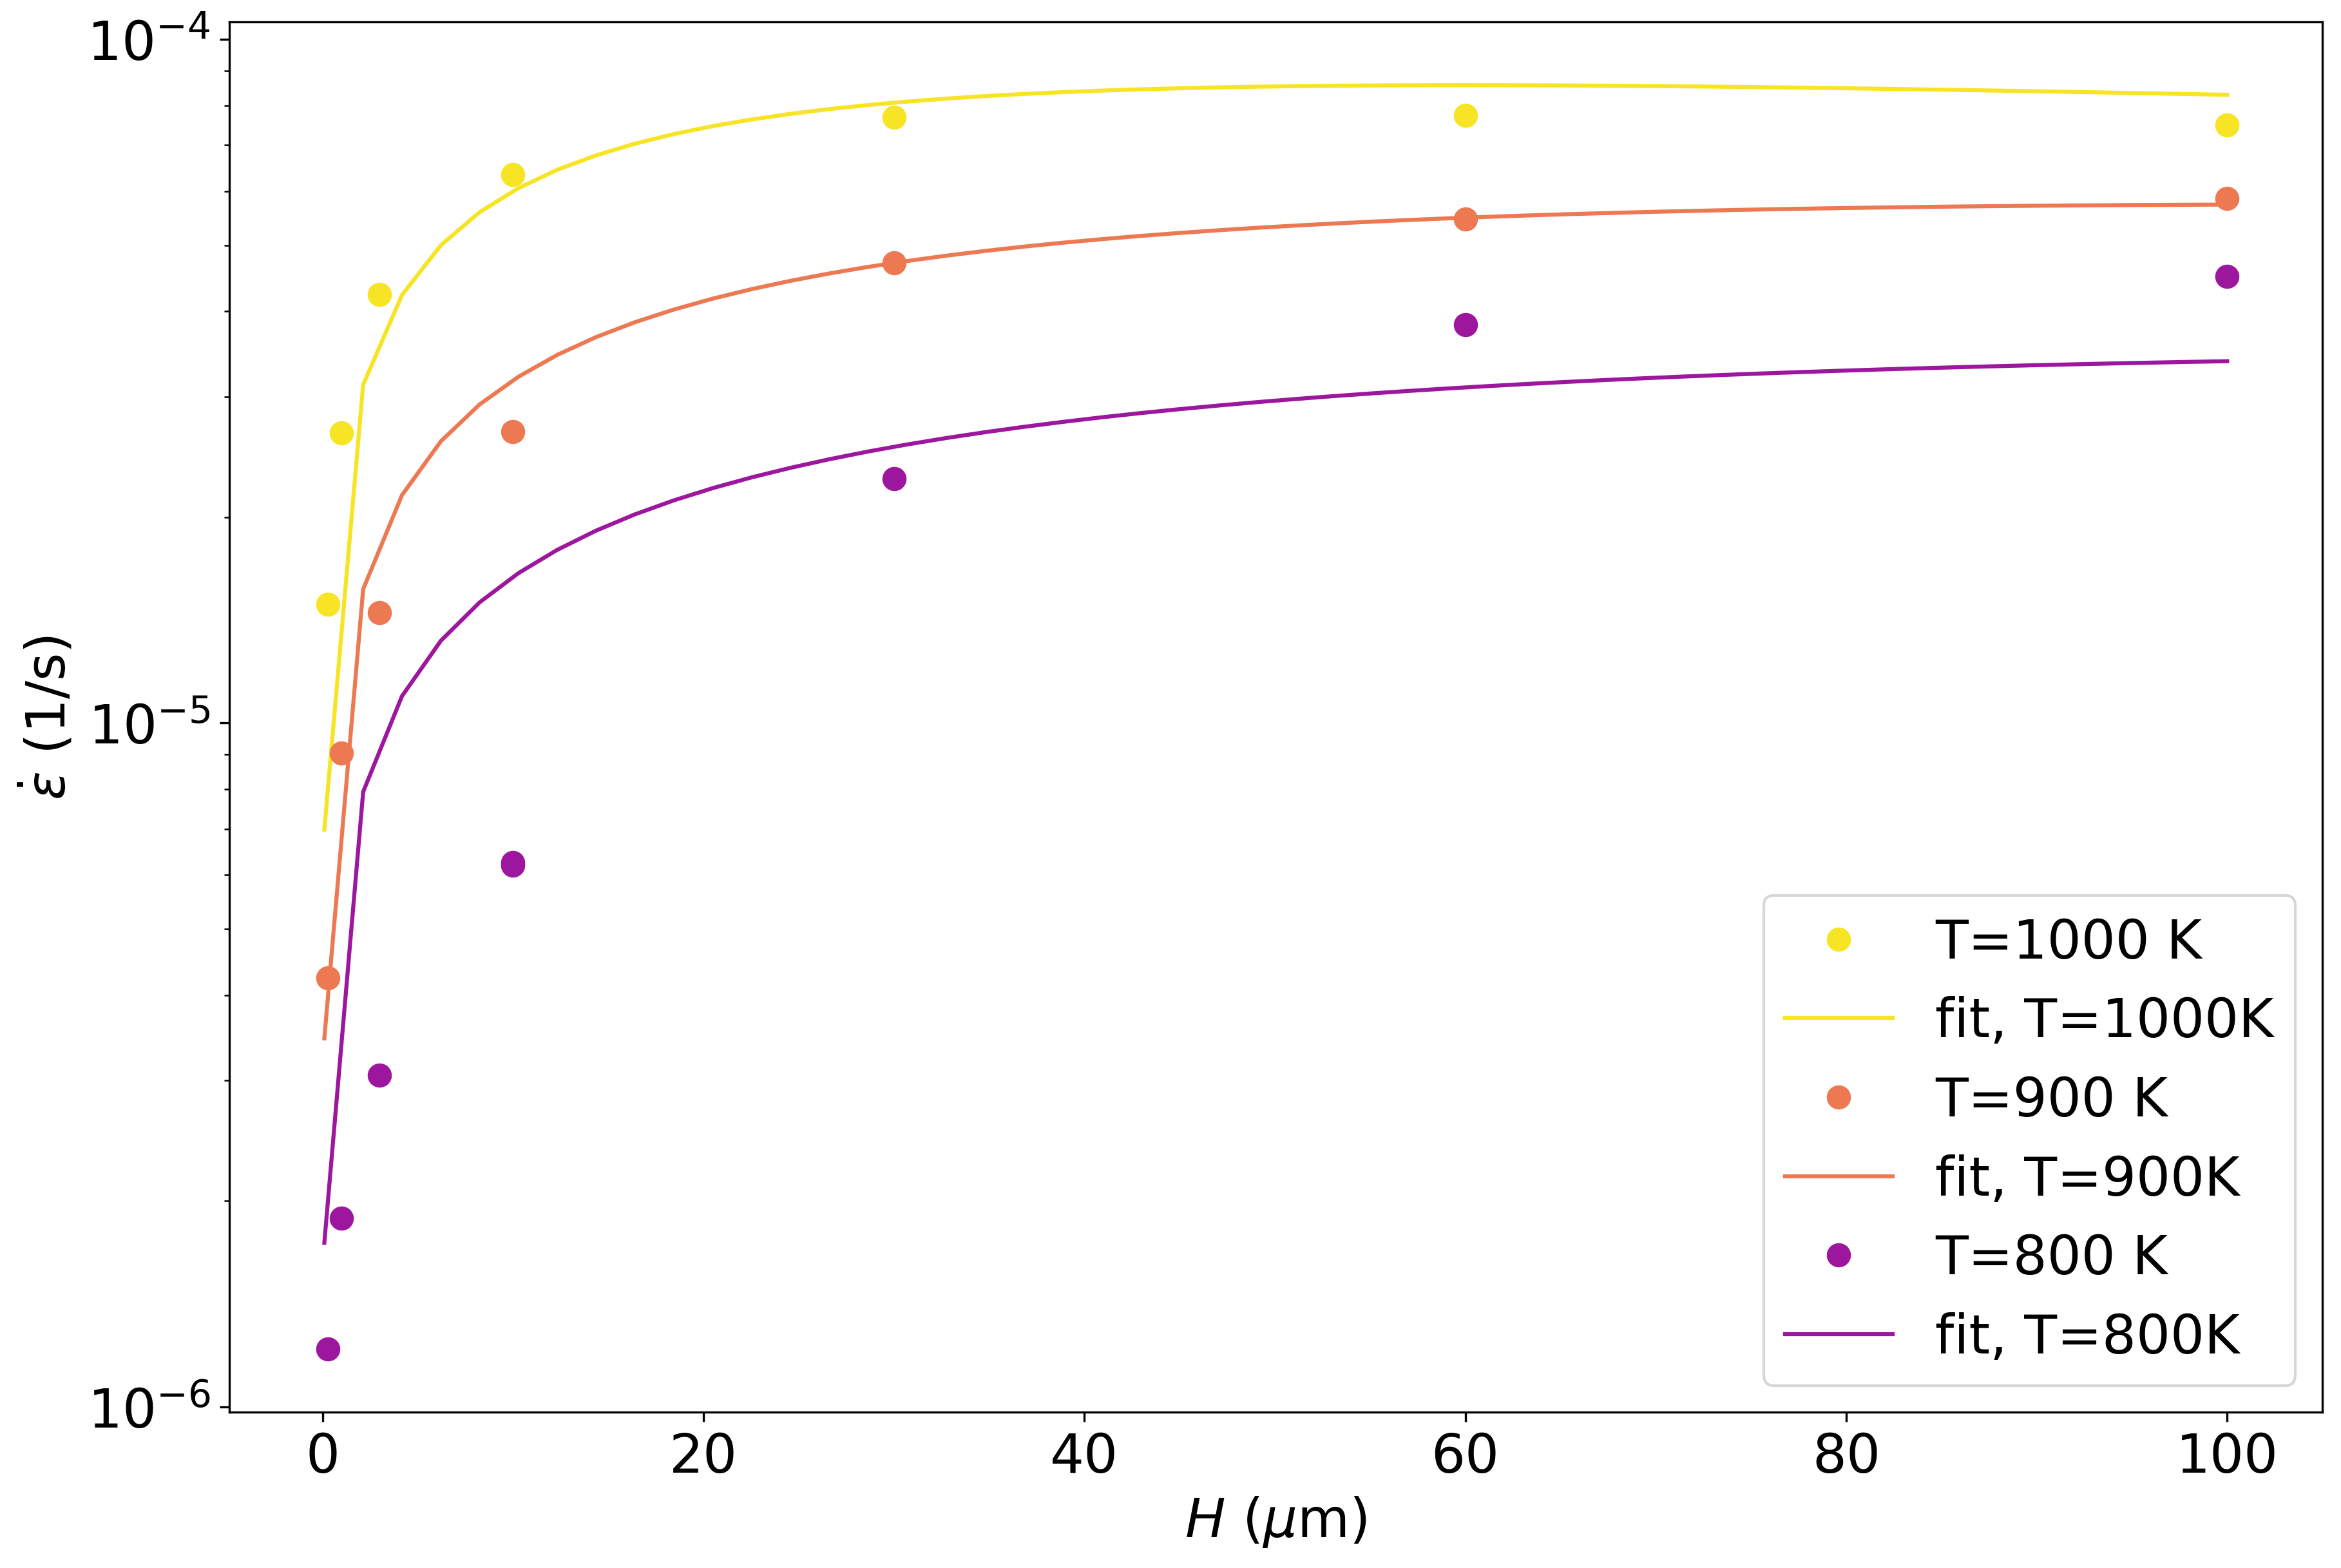

In [29]:
plt.rcParams["font.size"] = 20
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, constrained_layout=True)
sig = 100.
Ceff = C0 * 800. *np.sqrt(50)
#gs_list = [0.3, 1., 3., 10., 30., 60.]
xval = np.linspace(0.1, 100., 50)
xlabel = r"$H$ ($\mu$m)"
x_scale = lambda x : x
cmap = plt.cm.plasma
ngbl = 0.1
plfun = plt.semilogy
ind = np.nonzero(np.logical_and(np.isclose(temp_, 1000.), np.isclose(L_, ngbl)))[0]
eps_ref10 = np.asarray([H_[ind], psr_[ind]*1.e6])
err10 = err(Ceff, eps_ref10, 1000., tau=sig)
print(f'Mean abs. rel. error for T=1000K: {err10}')
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.95),
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=1000 K")#, Lgb={ngbl}"+r"$\mu$m")
plfun(xval, edot_ss(xval, sig, T=1000.), 
      linestyle = "solid",
      color=cmap(0.95),
      marker = "none",
      label = "fit, T=1000K")
#plt.semilogy(gs_, eps_dot(150, 1000., gs_), '-k')
ind = np.nonzero(np.logical_and(np.isclose(temp_, 900.), np.isclose(L_, ngbl)))[0]
eps_ref9 = np.asarray([H_[ind], psr_[ind]*1.e6])
err9 = err(Ceff, eps_ref10, 900., tau=sig)
print(f'Mean abs. rel. error for T=900K: {err9}')
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.667),
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=900 K")#, Lgb={ngbl}"+r"$\mu$m")
plfun(xval, edot_ss(xval, sig, T=900.), 
      linestyle = "solid",
      color=cmap(0.667),
      marker = "none",
      label = "fit, T=900K")
ind = np.nonzero(np.logical_and(np.isclose(temp_, 800.), np.isclose(L_, ngbl)))[0]
eps_ref8 = np.asarray([H_[ind], psr_[ind]*1.e6])
err8 = err(Ceff, eps_ref10, 800., tau=sig)
print(f'Mean abs. rel. error for T=800K: {err8}')
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.333),
         linestyle = "none",
         marker = 'o',
         markersize = 8,
         label=f"T=800 K")#, Lgb={ngbl}"+r"$\mu$m")
plfun(xval, edot_ss(xval, sig, T=800.), 
      linestyle = "solid",
      color=cmap(0.333),
      marker = "none",
      label = "fit, T=800K")
err_tot = (err10 + err9 + err8) / 3
print(f'Mean total error: {err_tot}')
plt.xlabel(xlabel)
plt.ylabel(r"$\dot\varepsilon$ (1/s)")
#plt.ylim(1.e-6, 1.e-4)
plt.legend(loc='lower right') #, bbox_to_anchor=(1.3, 1.02))
#plt.savefig('creep_rate_vs_H_tau50.pdf', dpi=300, format='pdf')
plt.show()

In [ ]:
gs_ = np.linspace(10., 100., 50)

plt.rcParams["font.size"] = 20
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, constrained_layout=True)
#gs_list = [0.3, 1., 3., 10., 30., 60.]
#xval = 1./np.sqrt(gs_list)
#x_scale = lambda x : 1./np.sqrt(x)
#xlabel = r"$1/\sqrt{H}$ ($\mu$m$^{-1/2}$)"
xlabel = r"$H$ ($\mu$m)"
x_scale = lambda x : x
cmap = plt.cm.plasma
ngbl = 0.1
plfun = plt.semilogy
ind = np.nonzero(np.logical_and(np.isclose(temp_, 1000.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.95),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=1000 K")#, Lgb={ngbl}"+r"$\mu$m")
#plt.semilogy(gs_, eps_dot(150, 1000., gs_), '-k')
ind = np.nonzero(np.logical_and(np.isclose(temp_, 900.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.667),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=900 K")#, Lgb={ngbl}"+r"$\mu$m")
ind = np.nonzero(np.logical_and(np.isclose(temp_, 800.), np.isclose(L_, ngbl)))[0]
plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
         color=cmap(0.333),
         linestyle = "solid",
         marker = 'o',
         markersize = 8,
         label=f"T=800 K")#, Lgb={ngbl}"+r"$\mu$m")
#ind = np.nonzero(np.logical_and(np.isclose(temp_,700.), np.isclose(L_, ngbl)))[0]
#ind = [i for i in ind if H_[i]>=30.]
#plfun(x_scale(H_[ind]), psr_[ind]*1.e6,
#         color=cmap(0.),
#         linestyle = "solid",
#         marker = 'o',
#         markersize = 8,
#         label=f"T=700 K")#, Lgb={ngbl}"+r"$\mu$m")
plt.xlabel(xlabel)
plt.ylabel(r"$\dot\varepsilon$ (1/s)")
plt.ylim(1.e-6, 1.e-4)
plt.legend(loc='lower right') #, bbox_to_anchor=(1.3, 1.02))
#plt.savefig('creep_rate_vs_H.pdf', dpi=300, format='pdf')
plt.show()

In [12]:
path = "../data/Res-tau50/"
fname = "gb_final_tau50_T900_H300_L1.h5"
gbr = dd.GB_dislocations(from_file=path+fname)
gbdd_init = {
    "temp": gbr.temp,
    "tau0": gbr.tau0,
    "Ngbn": gbr.Ngbn,
    "len_gb_seg": gbr.Dgp,
    "grain_size": gbr.D2,
    "maxdis": gbr.maxdis,
    "maxout": gbr.maxout,
    "niter": gbr.niter,
    "dtmax": gbr.dtmax,
    "screenout": gbr.screenout,
    "mu": gbr.mu,
    "nu": gbr.nu,
    "B": gbr.B,
    "delta": gbr.delta,
    "Qact": gbr.Qact,
    "drag": gbr.drag,
    "Dif_gb": gbr.Dif_gb,
}

pudis=gbr.pu_dis['position'][gbr.nout-1, :].copy()
vout=gbr.vout[gbr.nout-1, :, :].copy()
r_time=float(gbr.sim_time[gbr.nout-1])
nabs=gbr.nabs
gbdd_init.update({
    "maxout": 800,
    "niter": 80_000_000,
    "tfin": r_time + 2.0e9,
    "screenout": True,
})
print(gbdd_init)
gbdd = dd.GB_dislocations(**gbdd_init)
print(f"r_time={r_time}, nout={gbr.nout}, tfin={gbdd.tfin}")
gbdd.run_sim(pudis=pudis, vout=vout, r_time=r_time, nabs=nabs)
fname = (
            f"gb_final2_tau{int(gbdd.tau0)}_T{int(gbdd.temp)}_"
            f"H{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.h5"
        )
gbdd.save_hdf5(path+fname)


{'temp': np.float64(900.0), 'tau0': np.float64(50.0), 'Ngbn': 25, 'len_gb_seg': np.float64(0.1), 'grain_size': np.float64(30.0), 'maxdis': 4000, 'maxout': 800, 'niter': 80000000, 'dtmax': np.float64(2441.4062499999995), 'screenout': True, 'mu': np.float64(44000.0), 'nu': np.float64(0.3), 'B': np.float64(0.00025), 'delta': np.float64(0.004), 'Qact': np.float64(95000.0), 'drag': np.float64(500.0), 'Dif_gb': np.float64(10.0), 'tfin': 13000000945.38322}
Set mu: 44000.0
Set nu: 0.3
Set B: 0.00025
Set delta: 0.004
Set Qact: 95000.0
Set drag: 500.0
Set Dif_gb: 10.0
r_time=11000000945.38322, nout=800, tfin=13000000945.38322
 Restarting simulation from time =   11000000945.383221     
 with Npu =          64
 and Nabs absorbed dislocations: Nabs =          44
 Starting iteration for T, tau0, D2, Lgb, Ngbn   900.00000000000000        50.000000000000000        30.000000000000000       0.10000000000000001               25
 Iteration, dt, ttot(s), max(bdot), sum(bfield), Npu, Nabs, max(y)      8000

PosixPath('../data/Res-tau50/gb_final2_tau50_T900_H300_L1.h5')

In [ ]:
it = 500
plt.rcParams["font.size"] = 12
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
assert npu == gbdd.glob_data['n_slip_dis'][it]
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
print(f"Number of dislocations: {npu}, Simulation time: {gbdd.sim_time[it]*1.e-6}")

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
plot_stress_bfield(
    #file=f"sigpu_tau{int(gbdd.tau0)}_T{int(gbdd.temp)}_D{int(gbdd.D2*10)}_L{int(gbdd.Dgp*10)}.pdf", 
    cutoff=200
)
